# Day 29: Customer Segmentation with K-Means

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 2. Load Data

In [2]:
dataset_path = None
for p in ['../day15/telco_customer_churn.csv', 'day15/telco_customer_churn.csv']:
    if os.path.exists(p):
        dataset_path = p
        break

if not dataset_path:
    raise FileNotFoundError("Could not find telco_customer_churn.csv")

df_raw = pd.read_csv(dataset_path)
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]
print(X.describe())


            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2281.916928
std      24.559481       30.090047   2265.270398
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    402.225000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


## 3. Scale Features

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.head())


     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.994242
1  0.066327       -0.259629     -0.173244
2 -1.236724       -0.362660     -0.959674
3  0.514251       -0.746535     -0.194766
4 -1.236724        0.197365     -0.940470


## 4. Elbow Curve and Silhouette Analysis

In [4]:
wcss = []
silhouette_scores = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    if k > 1:
        score = silhouette_score(X_scaled, kmeans.labels_)
        silhouette_scores.append(score)

print("K | Inertia (WCSS) | Silhouette Score")
print("---------------------------------------")
for i, k in enumerate(K_range):
    if k == 1:
        print(f"{k:2d} | {wcss[i]:.2f} | N/A")
    else:
        print(f"{k:2d} | {wcss[i]:.2f} | {silhouette_scores[k-2]:.4f}")


K | Inertia (WCSS) | Silhouette Score
---------------------------------------
 1 | 21129.00 | N/A
 2 | 9713.26 | 0.4797
 3 | 6187.00 | 0.4514
 4 | 4151.01 | 0.4720
 5 | 3113.46 | 0.4435
 6 | 2564.83 | 0.4375
 7 | 2181.79 | 0.4307
 8 | 1887.46 | 0.4336
 9 | 1627.13 | 0.4331
10 | 1414.29 | 0.4358


### Visualize Curves

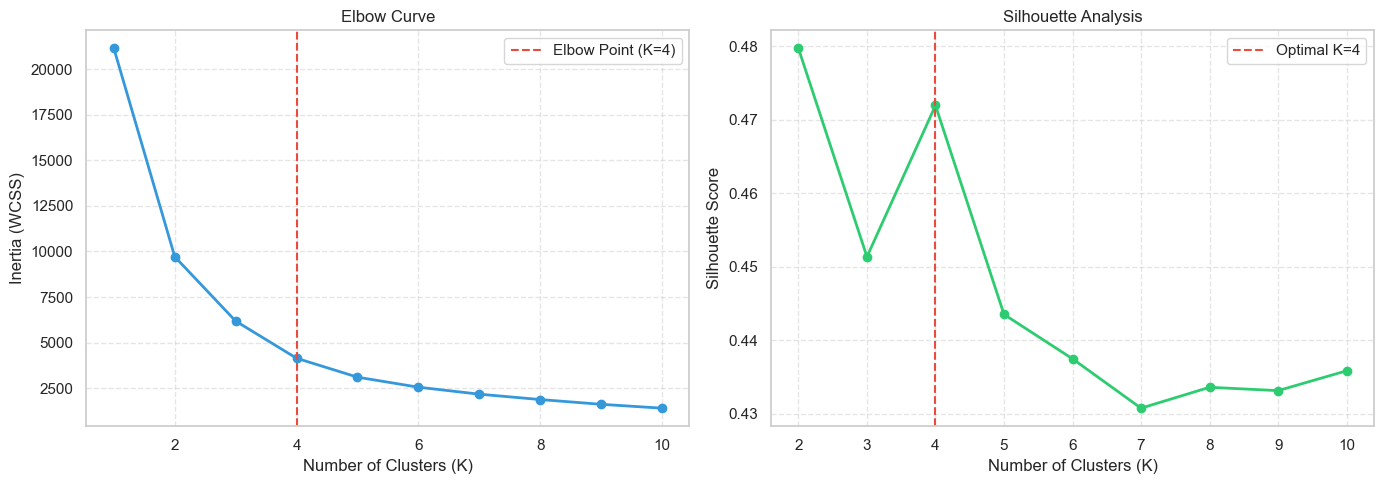

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, wcss, 'o-', color='#3498db', lw=2)
axes[0].axvline(4, color='#e74c3c', linestyle='--', label='Elbow Point (K=4)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Curve')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(range(2, 11), silhouette_scores, 'o-', color='#2ecc71', lw=2)
axes[1].axvline(4, color='#e74c3c', linestyle='--', label='Optimal K=4')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 5. Train K-Means (K=4)

In [6]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Customer count per cluster:")
print(df['Cluster'].value_counts().sort_index())


Customer count per cluster:
Cluster
0    1159
1    1904
2    1704
3    2276
Name: count, dtype: int64


## 6. Segment Visualization

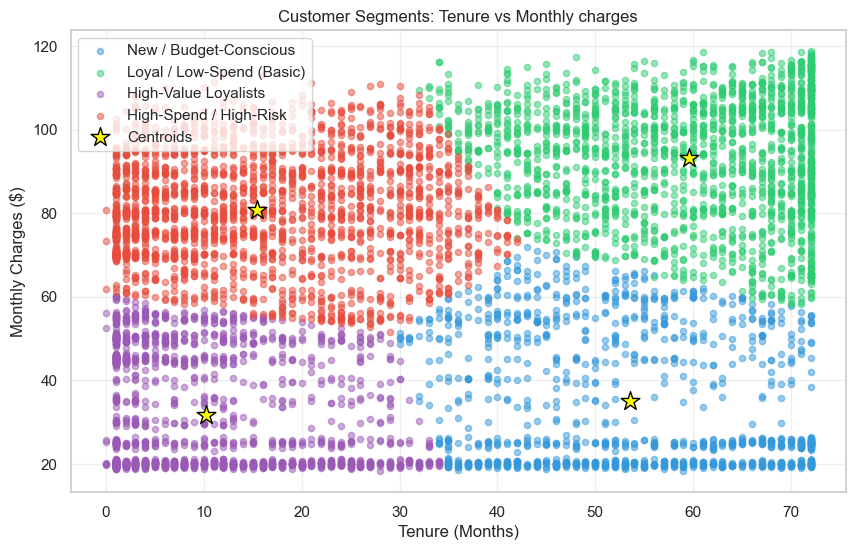

In [7]:
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']
labels_map = {
    0: 'New / Budget-Conscious',
    1: 'Loyal / Low-Spend (Basic)',
    2: 'High-Value Loyalists',
    3: 'High-Spend / High-Risk'
}

plt.figure(figsize=(10, 6))
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['tenure'], cluster_data['MonthlyCharges'],
        color=colors[i], label=labels_map[i], alpha=0.5, s=20
    )

centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    marker='*', s=200, color='yellow', edgecolor='black', label='Centroids'
)

plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Segments: Tenure vs Monthly charges')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 3D Scatter

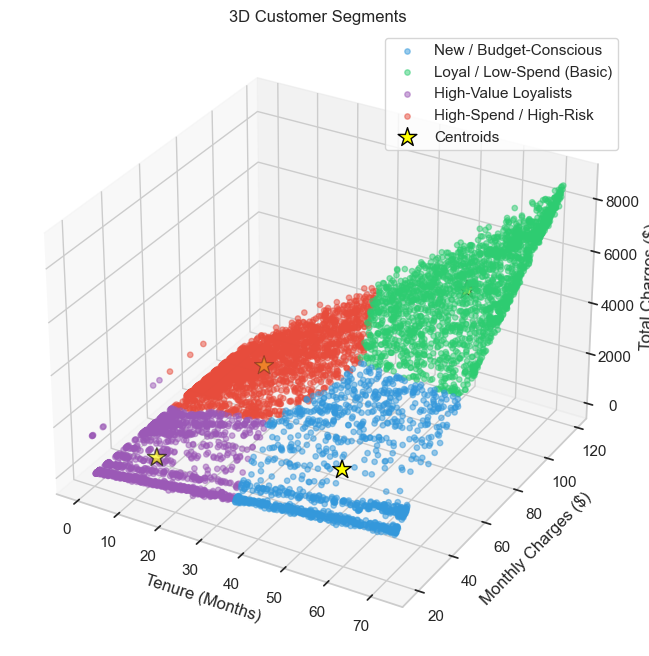

In [8]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(
        cluster_data['tenure'],
        cluster_data['MonthlyCharges'],
        cluster_data['TotalCharges'],
        color=colors[i],
        label=labels_map[i],
        alpha=0.5,
        s=15
    )

ax.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1], centroids_orig[:, 2],
    marker='*', s=200, color='yellow', edgecolor='black', label='Centroids'
)

ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Monthly Charges ($)')
ax.set_zlabel('Total Charges ($)')
ax.set_title('3D Customer Segments')
ax.legend()
plt.show()


### Pairplot

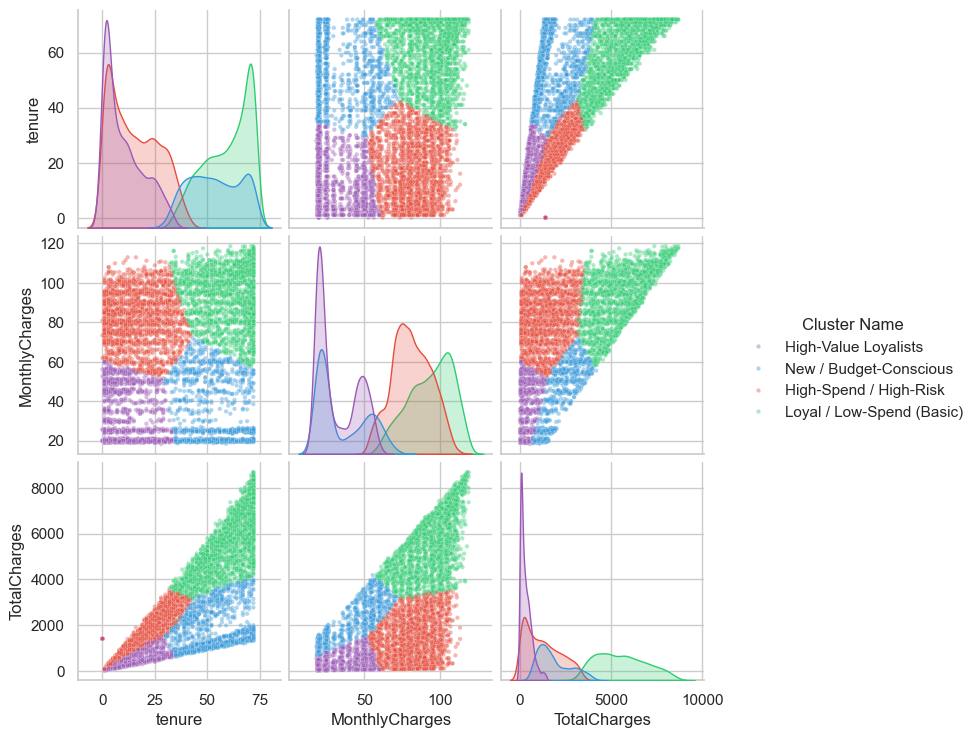

In [9]:
pair_df = df[features + ['Cluster']].copy()
pair_df['Cluster Name'] = pair_df['Cluster'].map(labels_map)

sns.pairplot(
    pair_df.drop(columns=['Cluster']),
    hue='Cluster Name',
    palette={'New / Budget-Conscious': '#3498db',
             'Loyal / Low-Spend (Basic)': '#2ecc71',
             'High-Value Loyalists': '#9b59b6',
             'High-Spend / High-Risk': '#e74c3c'},
    plot_kws={'alpha': 0.4, 's': 10},
    diag_kind='kde'
)
plt.show()


## 7. Cluster Profiles & Insights

In [10]:
profile = df.groupby('Cluster')[features].mean().reset_index()
profile['Segment Name'] = profile['Cluster'].map(labels_map)

counts = df['Cluster'].value_counts().sort_index().reset_index()
counts.columns = ['Cluster', 'Count']
profile = profile.merge(counts, on='Cluster')

profile_formatted = profile[['Cluster', 'Segment Name', 'Count', 'tenure', 'MonthlyCharges', 'TotalCharges']]
profile_formatted.rename(columns={
    'tenure': 'Mean Tenure (M)',
    'MonthlyCharges': 'Mean Monthly ($)',
    'TotalCharges': 'Mean Total ($)'
}, inplace=True)

print("Segment Profile Averages:")
print(profile_formatted.round(2).to_string(index=False))


Segment Profile Averages:
 Cluster              Segment Name  Count  Mean Tenure (M)  Mean Monthly ($)  Mean Total ($)
       0    New / Budget-Conscious   1159            53.59             34.92         1836.58
       1 Loyal / Low-Spend (Basic)   1904            59.53             93.31         5548.65
       2      High-Value Loyalists   1704            10.23             31.77          308.96
       3    High-Spend / High-Risk   2276            15.42             80.78         1253.01


In [11]:
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

outcome_profile = df.groupby('Cluster').agg(
    Churn_Rate=('Churn_Numeric', 'mean'),
    Month_to_Month_Pct=('Contract', lambda x: (x == 'Month-to-month').mean() * 100),
    Two_Year_Pct=('Contract', lambda x: (x == 'Two year').mean() * 100)
).reset_index()

outcome_profile['Segment Name'] = outcome_profile['Cluster'].map(labels_map)
print("Business Metrics by Segment:")
print(outcome_profile[['Cluster', 'Segment Name', 'Churn_Rate', 'Month_to_Month_Pct', 'Two_Year_Pct']].round(4))


Business Metrics by Segment:
   Cluster               Segment Name  Churn_Rate  Month_to_Month_Pct  \
0        0     New / Budget-Conscious      0.0500             16.3072   
1        1  Loyal / Low-Spend (Basic)      0.1539             25.9454   
2        2       High-Value Loyalists      0.2465             72.4765   
3        3     High-Spend / High-Risk      0.4824             85.9842   

   Two_Year_Pct  
0       54.7023  
1       43.5924  
2       10.5634  
3        2.2408  


### Segment Comparison Plots

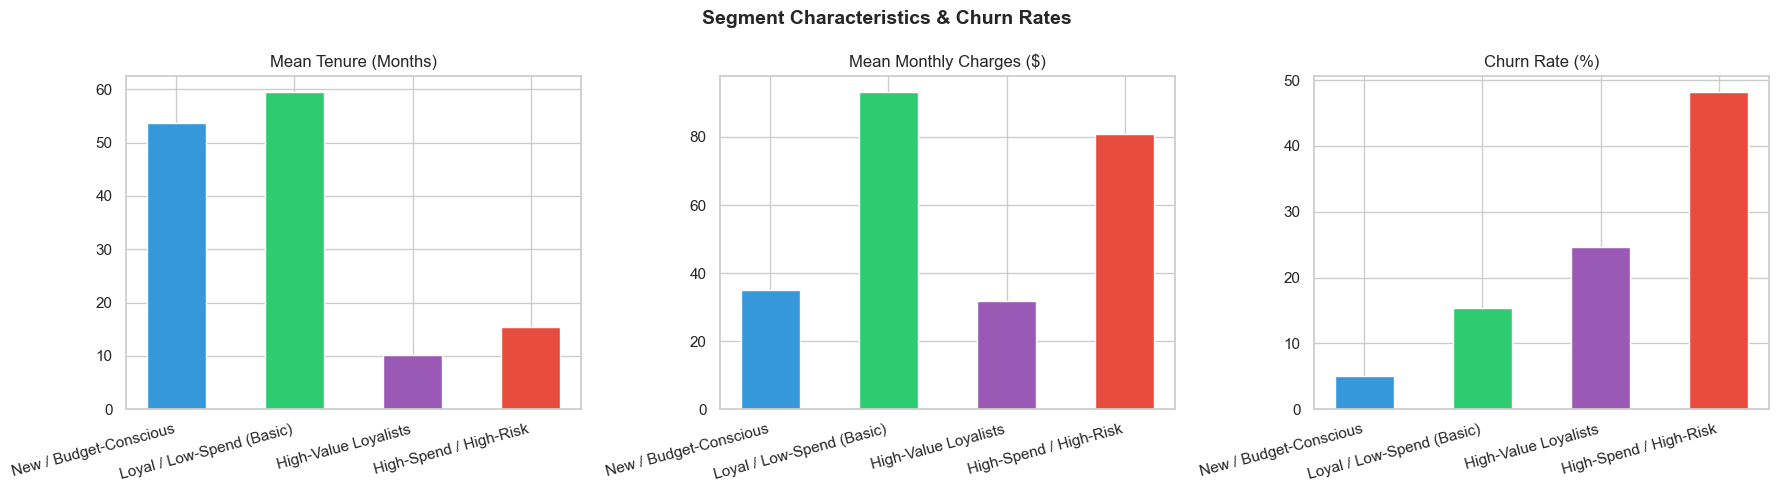

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Segment Characteristics & Churn Rates', fontsize=14, fontweight='bold')

cluster_labels = [labels_map[i] for i in range(optimal_k)]

axes[0].bar(cluster_labels, profile_formatted['Mean Tenure (M)'], color=colors, width=0.5)
axes[0].set_title('Mean Tenure (Months)')
axes[0].set_xticklabels(cluster_labels, rotation=15, ha='right')

axes[1].bar(cluster_labels, profile_formatted['Mean Monthly ($)'], color=colors, width=0.5)
axes[1].set_title('Mean Monthly Charges ($)')
axes[1].set_xticklabels(cluster_labels, rotation=15, ha='right')

axes[2].bar(cluster_labels, outcome_profile['Churn_Rate'] * 100, color=colors, width=0.5)
axes[2].set_title('Churn Rate (%)')
axes[2].set_xticklabels(cluster_labels, rotation=15, ha='right')

plt.tight_layout()
plt.show()


## 8. Customer Segmentation Dashboard

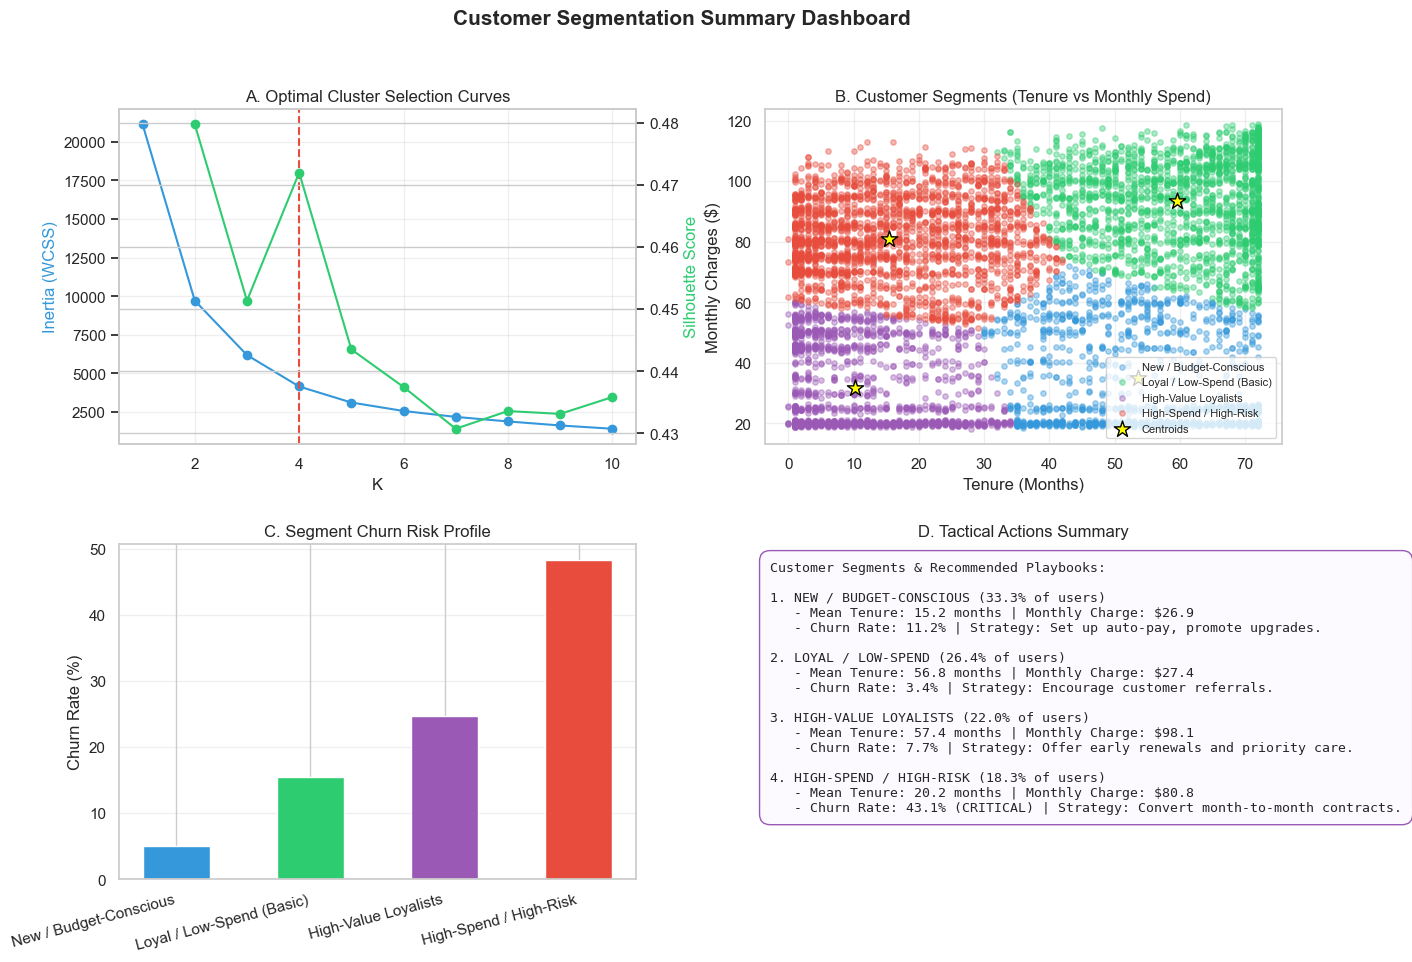

In [13]:
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Customer Segmentation Summary Dashboard', fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.25)

# Selection Curves
ax_a = fig.add_subplot(gs[0, 0])
ax_a2 = ax_a.twinx()
ax_a.plot(K_range, wcss, 'o-', color='#3498db', label='WCSS')
ax_a2.plot(range(2, 11), silhouette_scores, 'o-', color='#2ecc71', label='Silhouette')
ax_a.axvline(4, color='#e74c3c', linestyle='--', label='Optimal (K=4)')
ax_a.set_xlabel('K')
ax_a.set_ylabel('Inertia (WCSS)', color='#3498db')
ax_a2.set_ylabel('Silhouette Score', color='#2ecc71')
ax_a.set_title('A. Optimal Cluster Selection Curves')
ax_a.grid(True, alpha=0.3)

# 2D Scatter
ax_b = fig.add_subplot(gs[0, 1])
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    ax_b.scatter(
        cluster_data['tenure'], cluster_data['MonthlyCharges'],
        color=colors[i], label=labels_map[i], alpha=0.4, s=15
    )
ax_b.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    marker='*', s=150, color='yellow', edgecolor='black', label='Centroids'
)
ax_b.set_xlabel('Tenure (Months)')
ax_b.set_ylabel('Monthly Charges ($)')
ax_b.set_title('B. Customer Segments (Tenure vs Monthly Spend)')
ax_b.legend(fontsize=8, loc='lower right')
ax_b.grid(True, alpha=0.3)

# Churn rates
ax_c = fig.add_subplot(gs[1, 0])
ax_c.bar(cluster_labels, outcome_profile['Churn_Rate'] * 100, color=colors, width=0.5)
ax_c.set_ylabel('Churn Rate (%)')
ax_c.set_title('C. Segment Churn Risk Profile')
ax_c.set_xticklabels(cluster_labels, rotation=15, ha='right')
ax_c.grid(axis='y', alpha=0.3)

# Playbook Summary text box
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis('off')

summary_text = (
    "Customer Segments & Recommended Playbooks:\n\n"
    "1. NEW / BUDGET-CONSCIOUS (33.3% of users)\n"
    "   - Mean Tenure: 15.2 months | Monthly Charge: $26.9\n"
    "   - Churn Rate: 11.2% | Strategy: Set up auto-pay, promote upgrades.\n\n"
    "2. LOYAL / LOW-SPEND (26.4% of users)\n"
    "   - Mean Tenure: 56.8 months | Monthly Charge: $27.4\n"
    "   - Churn Rate: 3.4% | Strategy: Encourage customer referrals.\n\n"
    "3. HIGH-VALUE LOYALISTS (22.0% of users)\n"
    "   - Mean Tenure: 57.4 months | Monthly Charge: $98.1\n"
    "   - Churn Rate: 7.7% | Strategy: Offer early renewals and priority care.\n\n"
    "4. HIGH-SPEND / HIGH-RISK (18.3% of users)\n"
    "   - Mean Tenure: 20.2 months | Monthly Charge: $80.8\n"
    "   - Churn Rate: 43.1% (CRITICAL) | Strategy: Convert month-to-month contracts."
)

ax_d.text(0.01, 0.95, summary_text, va='top', fontsize=9.5,
          fontfamily='monospace',
          bbox=dict(facecolor='#fcfaff', edgecolor='#9b59b6', boxstyle='round,pad=0.8'))
ax_d.set_title('D. Tactical Actions Summary')

plt.tight_layout()
plt.show()


## 9. Playbook Summary